### Ridge Regression

##### Ridge regression is used to prevent the overfitting conditions by adding the square value of slope in the cost function

### Lasso Regression
##### Lasso is mainly used to scrap the important features and neglact the unwanted features it just adds the mode of the slope in the cost function to prevent overfitting

### ElasticNet
##### ElasticNet is the mixture of both L1 regulirization and L2 regulirization 

In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split


In [3]:
X,y = make_regression(
    n_samples=60, 
    n_features=100, 
    n_informative=10,  # Only 10 features actually matter; the other 90 are pure noise
    noise=25.0,        # Add a heavy dose of random noise
    random_state=42
)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)


In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

score = r2_score(y_test, lr.predict(X_test))
score2 = r2_score(y_train, lr.predict(X_train))
print(score)
print(score2)

0.7109369366023004
1.0


### Implementing it with ridge, lasso and elasticnet

In [6]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
ridge = Ridge()
lasso = Lasso()
elastic_net = ElasticNet(alpha=0.3, l1_ratio=0.5)
parameter = {
    "alpha" : [0.01,3.0,5.0,10.0, 100.0]
}

grid_search = GridSearchCV(
    estimator=elastic_net,
    param_grid=parameter,
    scoring= "r2",
    cv = 5
)

grid_search.fit(X_train_scaled, y_train)

best_ridge_model = grid_search.best_estimator_

train_preds = best_ridge_model.predict(X_train_scaled)
test_preds = best_ridge_model.predict(X_test_scaled)

print(r2_score(y_train, train_preds))
print(r2_score(y_test, test_preds))
print(best_ridge_model)

0.9999899776566372
0.7393843948056613
ElasticNet(alpha=0.01)


C:\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.310e+01, tolerance: 7.600e+01
  model = cd_fast.enet_coordinate_descent(
C:\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.528e+02, tolerance: 8.781e+01
  model = cd_fast.enet_coordinate_descent(
C:\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.960e+02, tolerance: 8.483e+01
  model = cd_fast.enet_

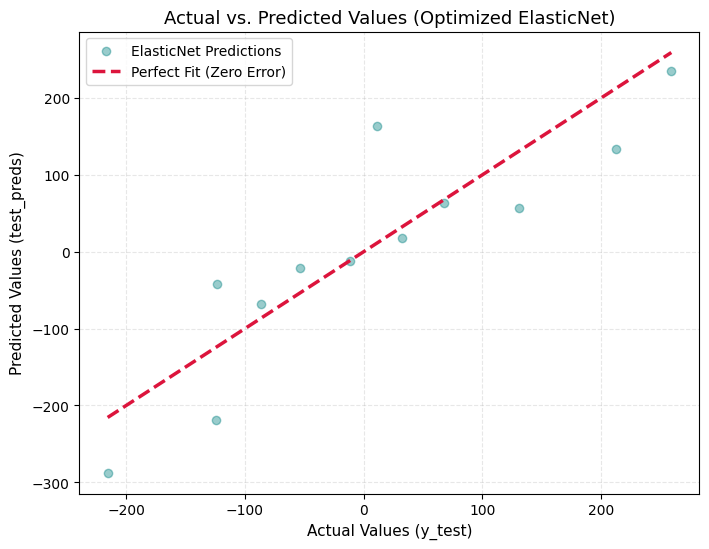

In [10]:
# Use your optimized predictions generated from test_preds
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))

# 1. Scatter plot of true test values vs your model predictions
plt.scatter(y_test, test_preds, color="teal", alpha=0.4, label="ElasticNet Predictions")

# 2. Draw a perfect fit diagonal baseline reference
perfect_line = [y_test.min(), y_test.max()]
plt.plot(
    perfect_line,
    perfect_line,
    color="crimson",
    linestyle="--",
    linewidth=2.5,
    label="Perfect Fit (Zero Error)",
)

# 3. Add details and labels
plt.xlabel("Actual Values (y_test)", fontsize=11)
plt.ylabel("Predicted Values (test_preds)", fontsize=11)
plt.title("Actual vs. Predicted Values (Optimized ElasticNet)", fontsize=13)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()